# **ML - Aprendizaje no Supervisado**

**Apellidos y Nombre:** Vasquez Caiza Juan Marelo.

**Carrera:** Ingenieria de Sistemas.

In [83]:
from sklearn.datasets import make_blobs
import numpy as np
import random

# **K-Means**

In [84]:
n_centers = random.randint(1,20)
print(f"Generando datos con {n_centers} centroides.")

Generando datos con 3 centroides.


In [85]:
blob_centers = np.random.uniform(low=-50, high=50, size=(n_centers, 2))
cluster_std = np.random.uniform(1.5, 3.0, size=n_centers)

X, y = make_blobs(n_samples=2000,
                  centers=blob_centers,
                  cluster_std=cluster_std,
                  random_state=42)

In [86]:
print(blob_centers)

[[-11.23492224 -18.38775446]
 [ -2.40481969  39.65531257]
 [-31.27634322  25.57523474]]


In [87]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

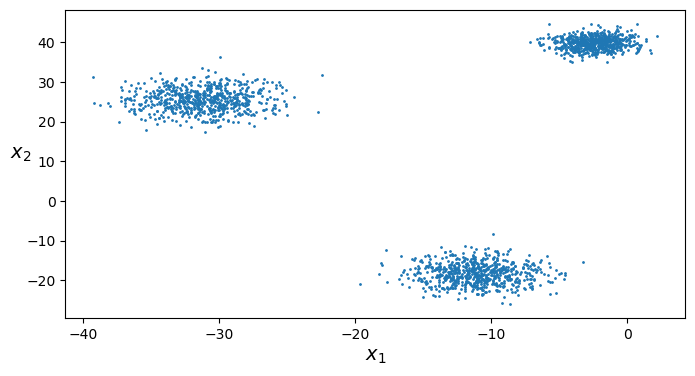

In [88]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

Aplicacion de K-Means

In [89]:
from sklearn.cluster import KMeans

k_test = n_centers

kmeans = KMeans(n_clusters=k_test, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([2, 1, 0, ..., 1, 2, 0], dtype=int32)

In [90]:
kmeans.cluster_centers_

array([[ -2.41778658,  39.7590093 ],
       [-11.13254884, -18.2881886 ],
       [-31.26988161,  25.51398772]])

Probamos con un nuevo array

In [91]:
X_test = np.array([[ 50, 50],   
                   [-50, -50],  
                   [ 0,  0],    
                   [ 2,  2],    
                   [ -1, 48]])  


y_test_pred = kmeans.predict(X_test)

y_test_pred

array([0, 1, 1, 1, 0], dtype=int32)

In [92]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

Visualizamos 

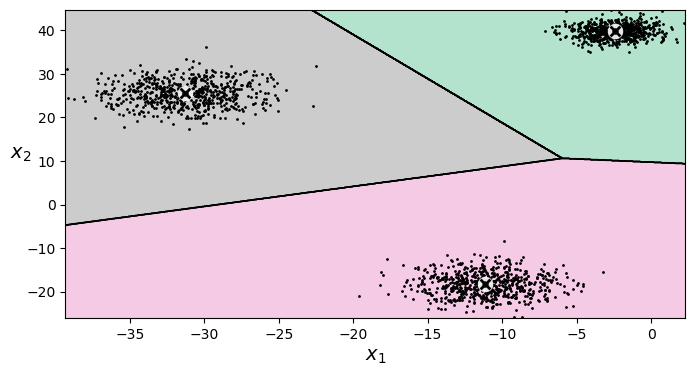

In [93]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

In [94]:
X_test_transformed = kmeans.transform(X_test)
X_test_transformed

array([[ 53.40882175,  91.6540519 ,  84.8784923 ],
       [101.5910763 ,  50.16291202,  77.80218298],
       [ 39.83245551,  21.41007907,  40.35801117],
       [ 38.01657035,  24.16763198,  40.74055278],
       [  8.36205995,  67.05812772,  37.70791006]])

Demostramos como diferentes inicializaciones y configuraciones pueden afectar el resultado del algoritmo K-Means. Estamos realizando una comparacion de modelos K-Means variando sus hiperparametros clave. 

In [95]:
kmeans_iter1 = KMeans(n_clusters=n_centers, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)

kmeans_iter2 = KMeans(n_clusters=n_centers, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

kmeans_iter3 = KMeans(n_clusters=n_centers, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)

In [96]:
kmeans_iter1.fit(X);

In [97]:
kmeans_iter2.fit(X);

In [98]:

kmeans_iter3.fit(X);

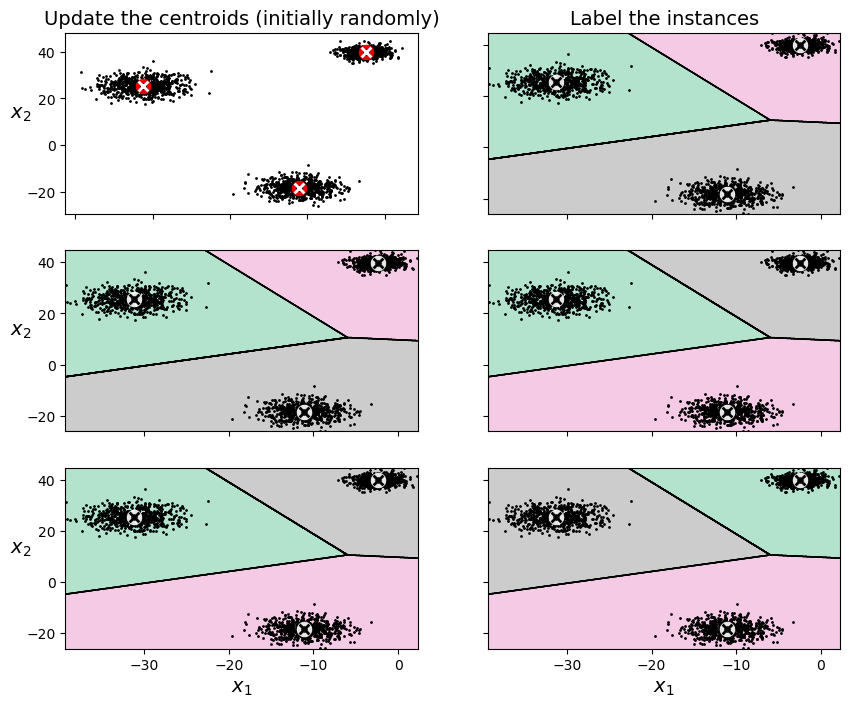

In [99]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Comparar visualmente los resultados de 2 modelos de clustering

In [100]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

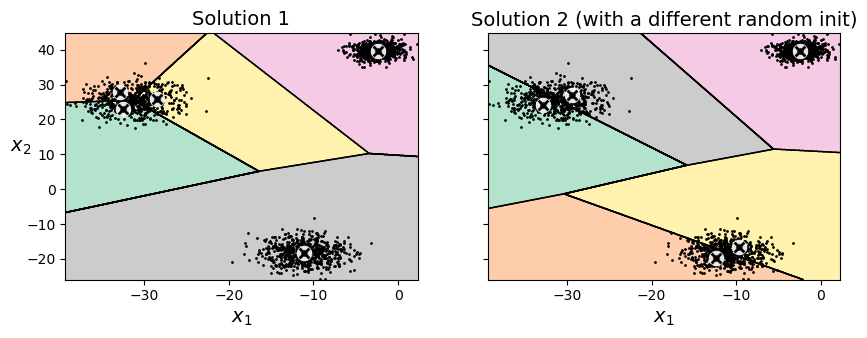

In [101]:
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

In [102]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                              algorithm="elkan", random_state=11)

In [103]:
kmeans_rnd_10_inits.fit(X);

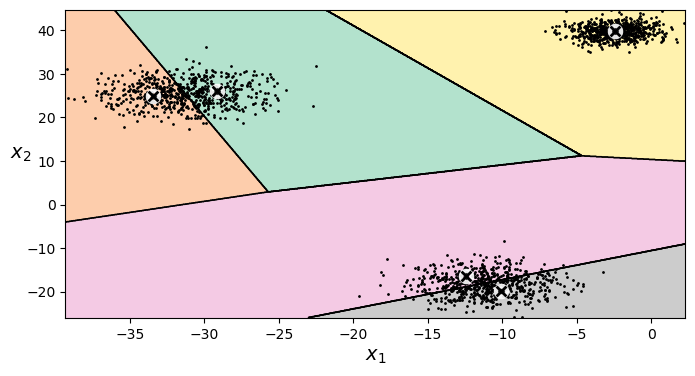

In [104]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

# **Metodo del Codo**

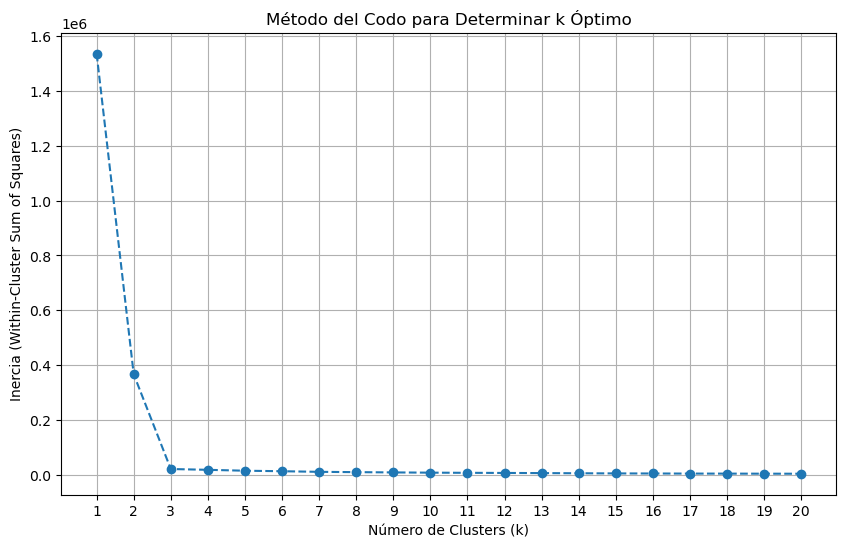

In [105]:
k_range = range(1, 21)
inertia_list = []

for k in k_range:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_elbow.fit(X)
    inertia_list.append(kmeans_elbow.inertia_)

# Graficar el resultado
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_list, marker='o', linestyle='--')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (Within-Cluster Sum of Squares)")
plt.title("Método del Codo para Determinar k Óptimo")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# **Silhouette Score**

k=2, Silhouette Score: 0.7434
k=3, Silhouette Score: 0.8893
k=4, Silhouette Score: 0.6918
k=5, Silhouette Score: 0.5087
k=6, Silhouette Score: 0.5153
k=7, Silhouette Score: 0.5230
k=8, Silhouette Score: 0.3279
k=9, Silhouette Score: 0.3228
k=10, Silhouette Score: 0.3181
k=11, Silhouette Score: 0.3210
k=12, Silhouette Score: 0.3177
k=13, Silhouette Score: 0.3150
k=14, Silhouette Score: 0.3246
k=15, Silhouette Score: 0.3306
k=16, Silhouette Score: 0.3252
k=17, Silhouette Score: 0.3191
k=18, Silhouette Score: 0.3149
k=19, Silhouette Score: 0.3168
k=20, Silhouette Score: 0.3125


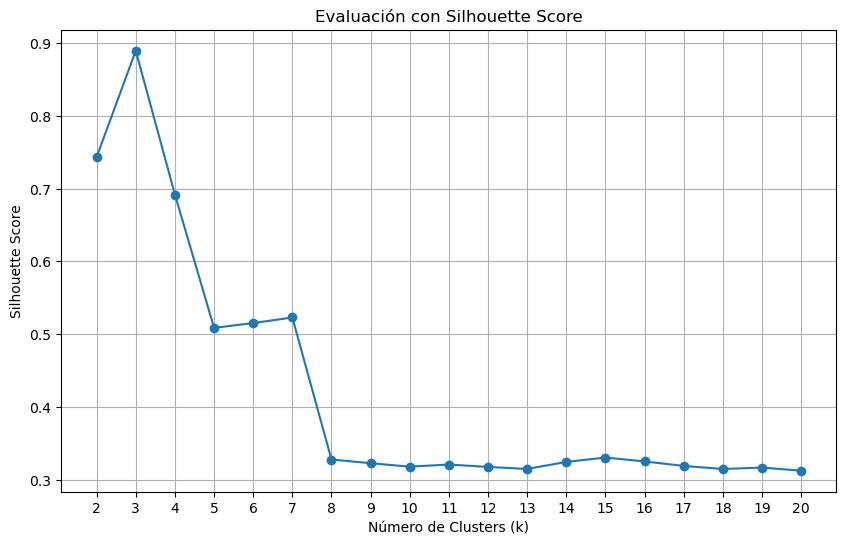


El valor de k óptimo según el Silhouette Score es: 3


In [106]:
from sklearn.metrics import silhouette_score

# Rango de k a evaluar (debe empezar en 2, ya que Silhouette no está definido para k=1)
k_range_silhouette = range(2, 21)
silhouette_scores = []

for k in k_range_silhouette:
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_sil.fit(X)
    # Calcular el score
    score = silhouette_score(X, kmeans_sil.labels_)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score: {score:.4f}")

# Graficar el resultado
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Evaluación con Silhouette Score")
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

# Identificar la k óptima por Silhouette Score
best_k_silhouette = k_range_silhouette[np.argmax(silhouette_scores)]
print(f"\nEl valor de k óptimo según el Silhouette Score es: {best_k_silhouette}")

Encontrando el numero optimo de grupos

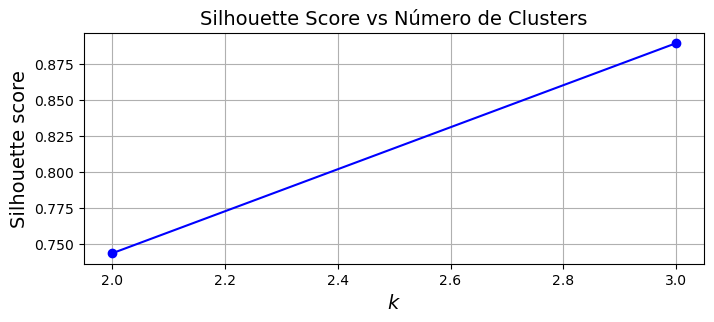

In [107]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 21)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))

kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

# Generar eje x para k de 2 hasta max_k
ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

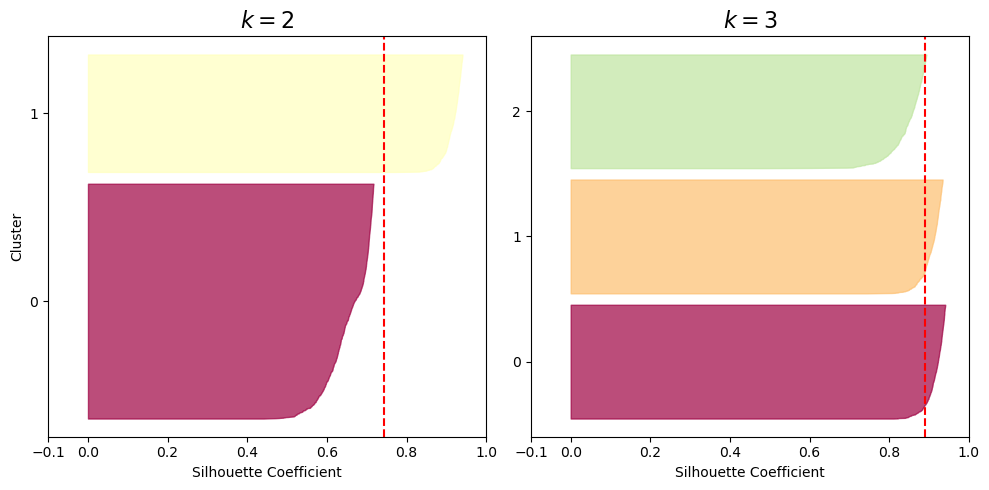

In [108]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

MAX_GRAPHS = 9
valid_ks_total = [k for k in range(2, 21) if k <= len(kmeans_per_k)] 
valid_ks = valid_ks_total[:MAX_GRAPHS]

num_plots = len(valid_ks)
rows = int(np.ceil(num_plots / 3)) 
cols = min(num_plots, 3)          


plt.figure(figsize=(5 * cols, 5 * rows)) 

for plot_idx, k in enumerate(valid_ks):
    
    plt.subplot(rows, cols, plot_idx + 1) 

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    
    
    if plot_idx % cols == 0:
        plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.tight_layout()
plt.show()